In [1]:
!pip install -q transformers datasets accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# prompt: mount google drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Changing to the working directory
%cd drive/MyDrive/Colab Notebooks/email_classification
!ls


/content/drive/MyDrive/Colab Notebooks/email_classification
'AI Training Dataset.zip'   DistilBERT.ipynb   gpt2_results   logs   results


In [4]:
!pwd

/content/drive/MyDrive/Colab Notebooks/email_classification


## Text file -> Dataframe

In [5]:
import zipfile
import os

zip_path = 'AI Training Dataset.zip'
extract_path = '/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

import pandas as pd

csv_path = os.path.join(extract_path, 'label.csv')
df = pd.read_csv(csv_path)

# Select Small Dataset
range1 = list(range(8, 58))       # 8~57 Pass
range2 = list(range(901, 951))    # 901~950 Fail

selected_filenames = [f"email{i}.txt" for i in range1 + range2]

df = df[df['filename'].isin(selected_filenames)].reset_index(drop=True)

# Create 'text' column
texts = []
for fname in df['filename']:
    file_path = os.path.join(extract_path, fname)
    with open(file_path, 'r', encoding='utf-8') as f:
        texts.append(f.read())

df['text'] = texts

# df.head() # idx | filename | status | text
df = df[['text', 'status']]
df.rename(columns={'status': 'label'}, inplace=True)  # Rename status -> label; for the use of HuggingFace Trainer or datasets.Dataset
df.head()


,text,label
0,Subject: Offer Confirmation – Software Enginee...,1
1,Subject: Offer Confirmation – Software Enginee...,1
2,Subject: Offer Confirmation – AI Researcher at...,1
3,Subject: Offer Confirmation – DevOps Engineer ...,1
4,Subject: Offer Confirmation – UI/UX Designer a...,1


## Train Test Split

In [6]:
from sklearn.model_selection import train_test_split

# train / temp (val + test)
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label'], random_state=42
)

# temp → validation / test
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

In [7]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)


## Call Model and Tokenizer

In [8]:
from transformers import BartTokenizer, BartForSequenceClassification

model_name = 'facebook/bart-base'
tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForSequenceClassification.from_pretrained(model_name, num_labels=2)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# label → labels
for ds in [train_dataset, val_dataset, test_dataset]:
    ds = ds.rename_column("label", "labels")


Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

## Trainer Setting

In [15]:
from transformers import TrainingArguments, Trainer, TrainerCallback
from sklearn.metrics import accuracy_score
import numpy as np

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir='./gpt2_results',
    eval_strategy="epoch",
    save_strategy="no",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    seed=42,
    logging_dir="./logs",
    report_to="none"  # Disable all integrations, including WandB
)

# Define a custom callback to disable WandB logging
class DisableWandbCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        # Do nothing to disable logging
        pass

# Create an instance of the custom callback
disable_wandb_callback = DisableWandbCallback()

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[disable_wandb_callback]
)


<ipython-input-15-17826653e92d>:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [16]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [17]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.006558,1.000000
2,No log,0.000003,1.000000
3,No log,0.000003,1.000000


TrainOutput(global_step=54, training_loss=0.0001778719705288057, metrics={'train_runtime': 897.5256, 'train_samples_per_second': 0.234, 'train_steps_per_second': 0.06, 'total_flos': 32202161510400.0, 'train_loss': 0.0001778719705288057, 'epoch': 3.0})

In [18]:
trainer.evaluate(test_dataset)


{'eval_loss': 2.177552914872649e-06,
 'eval_accuracy': 1.0,
 'eval_runtime': 17.3353,
 'eval_samples_per_second': 0.865,
 'eval_steps_per_second': 0.231,
 'epoch': 3.0}

In [19]:
results = trainer.predict(test_dataset)
print("Test Accuracy:", results.metrics['test_accuracy'])


Test Accuracy: 1.0


In [20]:

predictions = trainer.predict(test_dataset)

logits = predictions.predictions
predicted_labels = np.argmax(logits, axis=1)

true_labels = predictions.label_ids

# Fetch text
# test_dataset (HuggingFace Dataset) -> to_pandas() convert
df_test = test_dataset.to_pandas()

# Add label column
df_test['true_label'] = true_labels
df_test['predicted_label'] = predicted_labels

# Print N samples
sample_n = 10
print(df_test[['text', 'true_label', 'predicted_label']].sample(sample_n))


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 15) + inhomogeneous part.

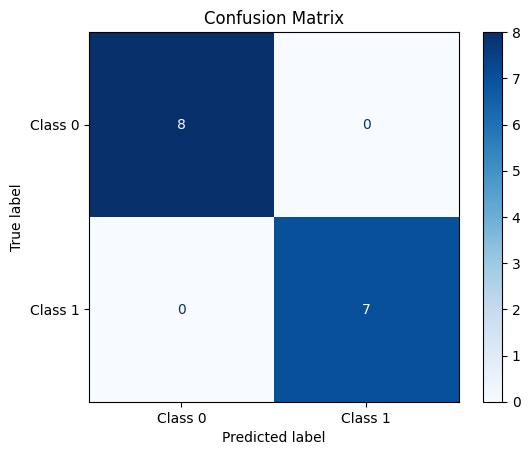

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
